In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Load saved embeddings + labels
X = np.load("distilbert_embeddings.npy")
y = np.load("labels.npy")

# Train-test split (stratify removed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Get unique classes - make sure we only have 0-17
classes = np.unique(y)
print(f"Unique classes found: {classes}")
print(f"Number of classes: {len(classes)}")

# Verify we have classes 0-21
expected_classes = np.arange(22)
missing_classes = set(expected_classes) - set(classes)
extra_classes = set(classes) - set(expected_classes)

if missing_classes:
    print(f"Warning: Missing classes: {missing_classes}")
if extra_classes:
    print(f"Warning: Extra classes found: {extra_classes}")
    # Filter out any class 22 or higher
    mask = y < 22
    X = X[mask]
    y = y[mask]
    print(f"Filtered dataset to remove classes >= 22")
    # Re-split after filtering
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42
    )
    classes = np.unique(y)

# Sort classes to ensure 0-17 order
classes = np.sort(classes)
n_classes = len(classes)
print(f"Final classes: {classes}")
print(f"Final number of classes: {n_classes}")

# Specificity (macro)
def specificity_macro(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    n = cm.shape[0]
    specs = []
    for i in range(n):
        TN = cm.sum() - (cm[i].sum() + cm[:, i].sum() - cm[i, i])
        FP = cm[:, i].sum() - cm[i, i]
        specs.append(TN / (TN + FP) if (TN + FP) > 0 else 0)
    return np.mean(specs)

# Models
models = {
    "RandomForest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=150, random_state=42),
    "SVM": SVC(kernel="linear", probability=True, random_state=42)  # Enable probability for ROC
}

# Optional models
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(n_estimators=200, n_jobs=-1, random_state=42)
except:
    pass

# Create figure for ROC curves comparison
fig_combined, axes_combined = plt.subplots(2, 2, figsize=(16, 14))
axes_combined = axes_combined.ravel()

# Train + Evaluate
model_count = 0
for name, model in models.items():
    print("\n" + "="*60)
    print(" " * 20 + f"{name}")
    print("="*60)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    spec = specificity_macro(y_test, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (macro): {prec:.4f}")
    print(f"Recall (macro): {rec:.4f}")
    print(f"F1-score (macro): {f1:.4f}")
    print(f"Specificity (macro): {spec:.4f}")
    
    # ==================== CONFUSION MATRIX PLOT ====================
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Count'},
                square=True)
    plt.title(f'Confusion Matrix - {name}\n(22 Classes: 0-21)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Labels', fontsize=14)
    plt.ylabel('True Labels', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    # Add accuracy in the plot
    plt.figtext(0.5, 0.01, 
                f'Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}', 
                ha='center', fontsize=12, 
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✓ Confusion matrix saved as 'confusion_matrix_{name.lower().replace(' ', '_')}.png'")
    
    # ==================== ROC CURVE FOR EACH CLASS ====================
    print(f"\nROC Curve Analysis for {name}:")
    
    # Get probability scores for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        if y_score.ndim == 1:
            y_score = y_score.reshape(-1, 1)
    else:
        print(f"  ⚠️ {name} doesn't support probability scores. Skipping ROC analysis.")
        continue
    
    # Binarize the test labels for multiclass ROC
    y_test_bin = label_binarize(y_test, classes=classes)
    
    # Compute ROC curve and ROC area for each class
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    # Make sure we only process the classes we have (0-17)
    for i, class_label in enumerate(classes):
        if y_score.shape[1] > i:
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            print(f"  Class {class_label:2d}: AUC = {roc_auc[i]:.4f}")
    
    # Plot ROC curves for all classes in one figure
    plt.figure(figsize=(16, 14))
    
    # Create a color palette for 22 classes
    colors = plt.cm.tab20(np.linspace(0, 1, n_classes))
    
    for i, class_label in enumerate(classes):
        if i in fpr:  # Check if ROC was computed for this class
            plt.plot(fpr[i], tpr[i], color=colors[i], lw=2.5, alpha=0.8,
                    label=f'Class {class_label:2d} (AUC = {roc_auc[i]:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.6, label='Random (AUC = 0.500)')
    
    # Calculate micro-average ROC
    if y_score.ndim > 1 and y_score.shape[1] > 1:
        fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc_micro = auc(fpr_micro, tpr_micro)
        plt.plot(fpr_micro, tpr_micro, color='black', lw=3, linestyle=':',
                label=f'Micro-average (AUC = {roc_auc_micro:.3f})')
        print(f"  Micro-average AUC: {roc_auc_micro:.4f}")
    
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title(f'ROC Curves for All {n_classes} Classes (0-{n_classes-1}) - {name}', 
              fontsize=16, fontweight='bold', pad=20)
    
    # Create legend with multiple columns
    plt.legend(loc='lower right', fontsize=9, ncol=2, frameon=True, 
               framealpha=0.9, title=f'Classes (0-{n_classes-1})')
    
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.axhline(y=0, color='k', alpha=0.3)
    plt.axvline(x=0, color='k', alpha=0.3)
    plt.axhline(y=1, color='k', alpha=0.3)
    plt.axvline(x=1, color='k', alpha=0.3)
    
    # Add model performance metrics to ROC plot
    plt.figtext(0.5, 0.01, f'Accuracy: {acc:.4f} | F1-Score: {f1:.4f}', 
                ha='center', fontsize=12, 
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(f'roc_curve_all_classes_{name.lower().replace(" ", "_")}.png', 
                dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✓ ROC curve saved as 'roc_curve_all_classes_{name.lower().replace(' ', '_')}.png'")
    
    # ==================== COMBINED ROC PLOT (All models comparison) ====================
    if model_count < len(axes_combined):
        ax = axes_combined[model_count]
        
        # Plot ROC for each class
        for i, class_label in enumerate(classes):
            if i in fpr:  # Check if ROC was computed for this class
                ax.plot(fpr[i], tpr[i], color=colors[i], lw=1.5, alpha=0.6)
        
        # Add micro-average if available
        if 'roc_auc_micro' in locals():
            ax.plot(fpr_micro, tpr_micro, color='black', lw=2.5, 
                   linestyle='--', label=f'Micro-avg (AUC = {roc_auc_micro:.3f})')
        
        ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_title(f'{name}\nAcc: {acc:.3f}, F1: {f1:.3f}', fontsize=12, fontweight='bold')
        ax.set_xlabel('False Positive Rate', fontsize=10)
        ax.set_ylabel('True Positive Rate', fontsize=10)
        ax.grid(True, alpha=0.2)
        ax.legend(loc='lower right', fontsize=8)
        
        model_count += 1
    
    print("-"*60)

# Save the combined ROC comparison figure
if model_count > 0:
    # Remove unused subplots
    for i in range(model_count, len(axes_combined)):
        fig_combined.delaxes(axes_combined[i])
    
    fig_combined.suptitle(f'ROC Curves Comparison - All Models (22 Classes: 0-21)', 
                         fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('roc_curves_comparison_all_models.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("\n✓ Combined ROC comparison saved as 'roc_curves_comparison_all_models.png'")

print("\n" + "="*60)
print("ALL VISUALIZATIONS COMPLETED")
print("="*60)
print("\nGenerated files:")
for name in models.keys():
    print(f"  • confusion_matrix_{name.lower().replace(' ', '_')}.png")
    print(f"  • roc_curve_all_classes_{name.lower().replace(' ', '_')}.png")
print("  • roc_curves_comparison_all_models.png")
print("\nEach confusion matrix shows exactly 22 classes (0-21).")
print("Each ROC curve shows all 22 classes with individual AUC scores.")

Unique classes found: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Number of classes: 22
Final classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Final number of classes: 22

                    RandomForest
Accuracy: 0.1802
Precision (macro): 0.1588
Recall (macro): 0.1814
F1-score (macro): 0.1667
Specificity (macro): 0.9610
✓ Confusion matrix saved as 'confusion_matrix_randomforest.png'

ROC Curve Analysis for RandomForest:
  Class  0: AUC = 0.3395
  Class  1: AUC = 0.8574
  Class  2: AUC = 0.7421
  Class  3: AUC = 0.4834
  Class  4: AUC = 0.6841
  Class  5: AUC = 0.6466
  Class  6: AUC = 0.7982
  Class  7: AUC = 0.8447
  Class  8: AUC = 0.6820
  Class  9: AUC = 0.4818
  Class 10: AUC = 0.7574
  Class 11: AUC = 0.6717
  Class 12: AUC = 0.9891
  Class 13: AUC = 0.5472
  Class 14: AUC = 0.5708
  Class 15: AUC = 0.6423
  Class 16: AUC = 0.9051
  Class 17: AUC = 0.8665
  Class 18: AUC = 0.6290
  Class 19: AUC = 0.6081
  Class 20: AUC = 0.59

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.1911
Precision (macro): 0.1652
Recall (macro): 0.1917
F1-score (macro): 0.1644
Specificity (macro): 0.9615
✓ Confusion matrix saved as 'confusion_matrix_adaboost.png'

ROC Curve Analysis for AdaBoost:
  Class  0: AUC = 0.5638
  Class  1: AUC = 0.8062
  Class  2: AUC = 0.7329
  Class  3: AUC = 0.5952
  Class  4: AUC = 0.7158
  Class  5: AUC = 0.6688
  Class  6: AUC = 0.7864
  Class  7: AUC = 0.8304
  Class  8: AUC = 0.7229
  Class  9: AUC = 0.6079
  Class 10: AUC = 0.7723
  Class 11: AUC = 0.6491
  Class 12: AUC = 0.9796
  Class 13: AUC = 0.6728
  Class 14: AUC = 0.6784
  Class 15: AUC = 0.6767
  Class 16: AUC = 0.8630
  Class 17: AUC = 0.7875
  Class 18: AUC = 0.7086
  Class 19: AUC = 0.7033
  Class 20: AUC = 0.6685
  Class 21: AUC = 0.6918
  Micro-average AUC: 0.7389
✓ ROC curve saved as 'roc_curve_all_classes_adaboost.png'
------------------------------------------------------------

                    SVM
Accuracy: 0.4905
Precision (macro): 0.4875
Recall (macro): 0.4906

XGBOOST - ROC Curve & Confusion Matrix
Classes: 18 (0-17)
Train: 52798, Test: 13200

Training XGBoost...


C:\ProgramData\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:36:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Performance Metrics:
Accuracy:    0.2797
Precision:   0.2225
Recall:      0.1924
F1-Score:    0.1954

Generating Confusion Matrix...


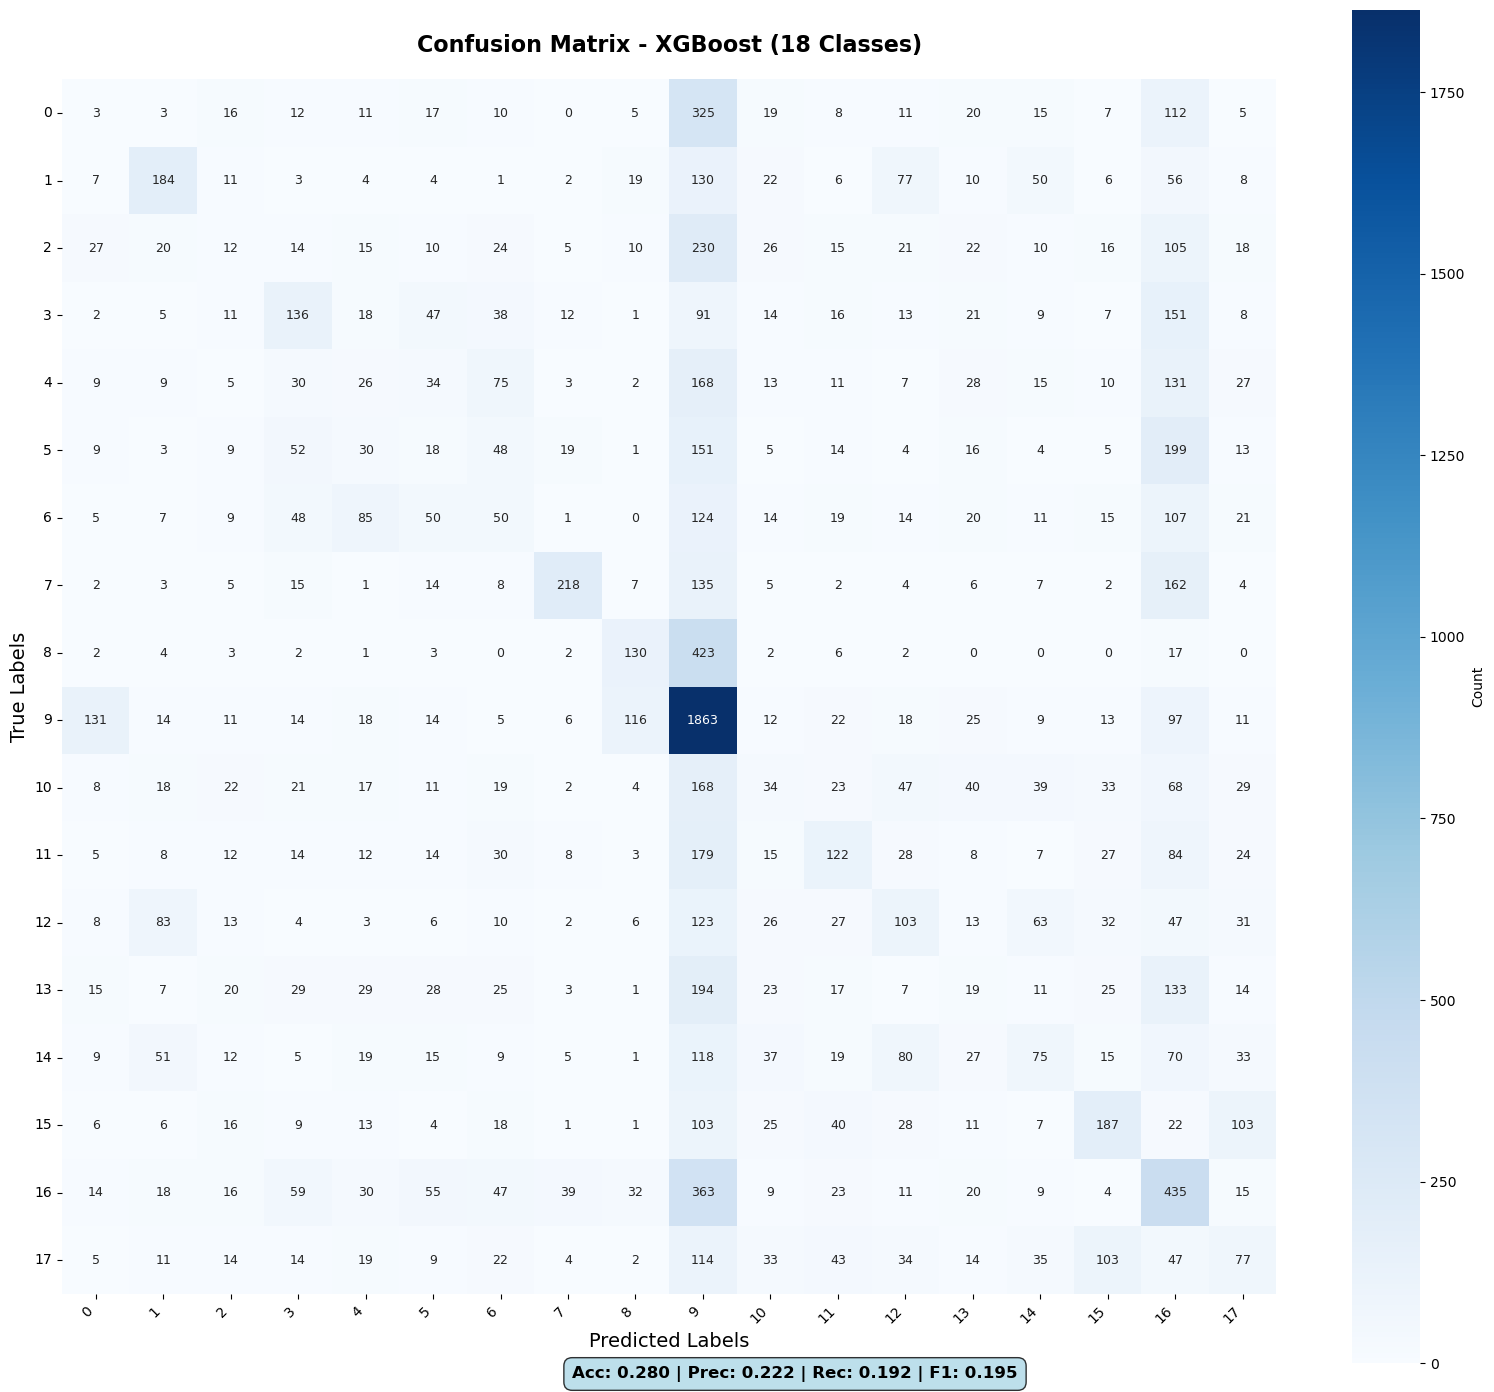

✓ Confusion matrix saved as 'confusion_matrix_xgboost.png'

Generating ROC Curves...


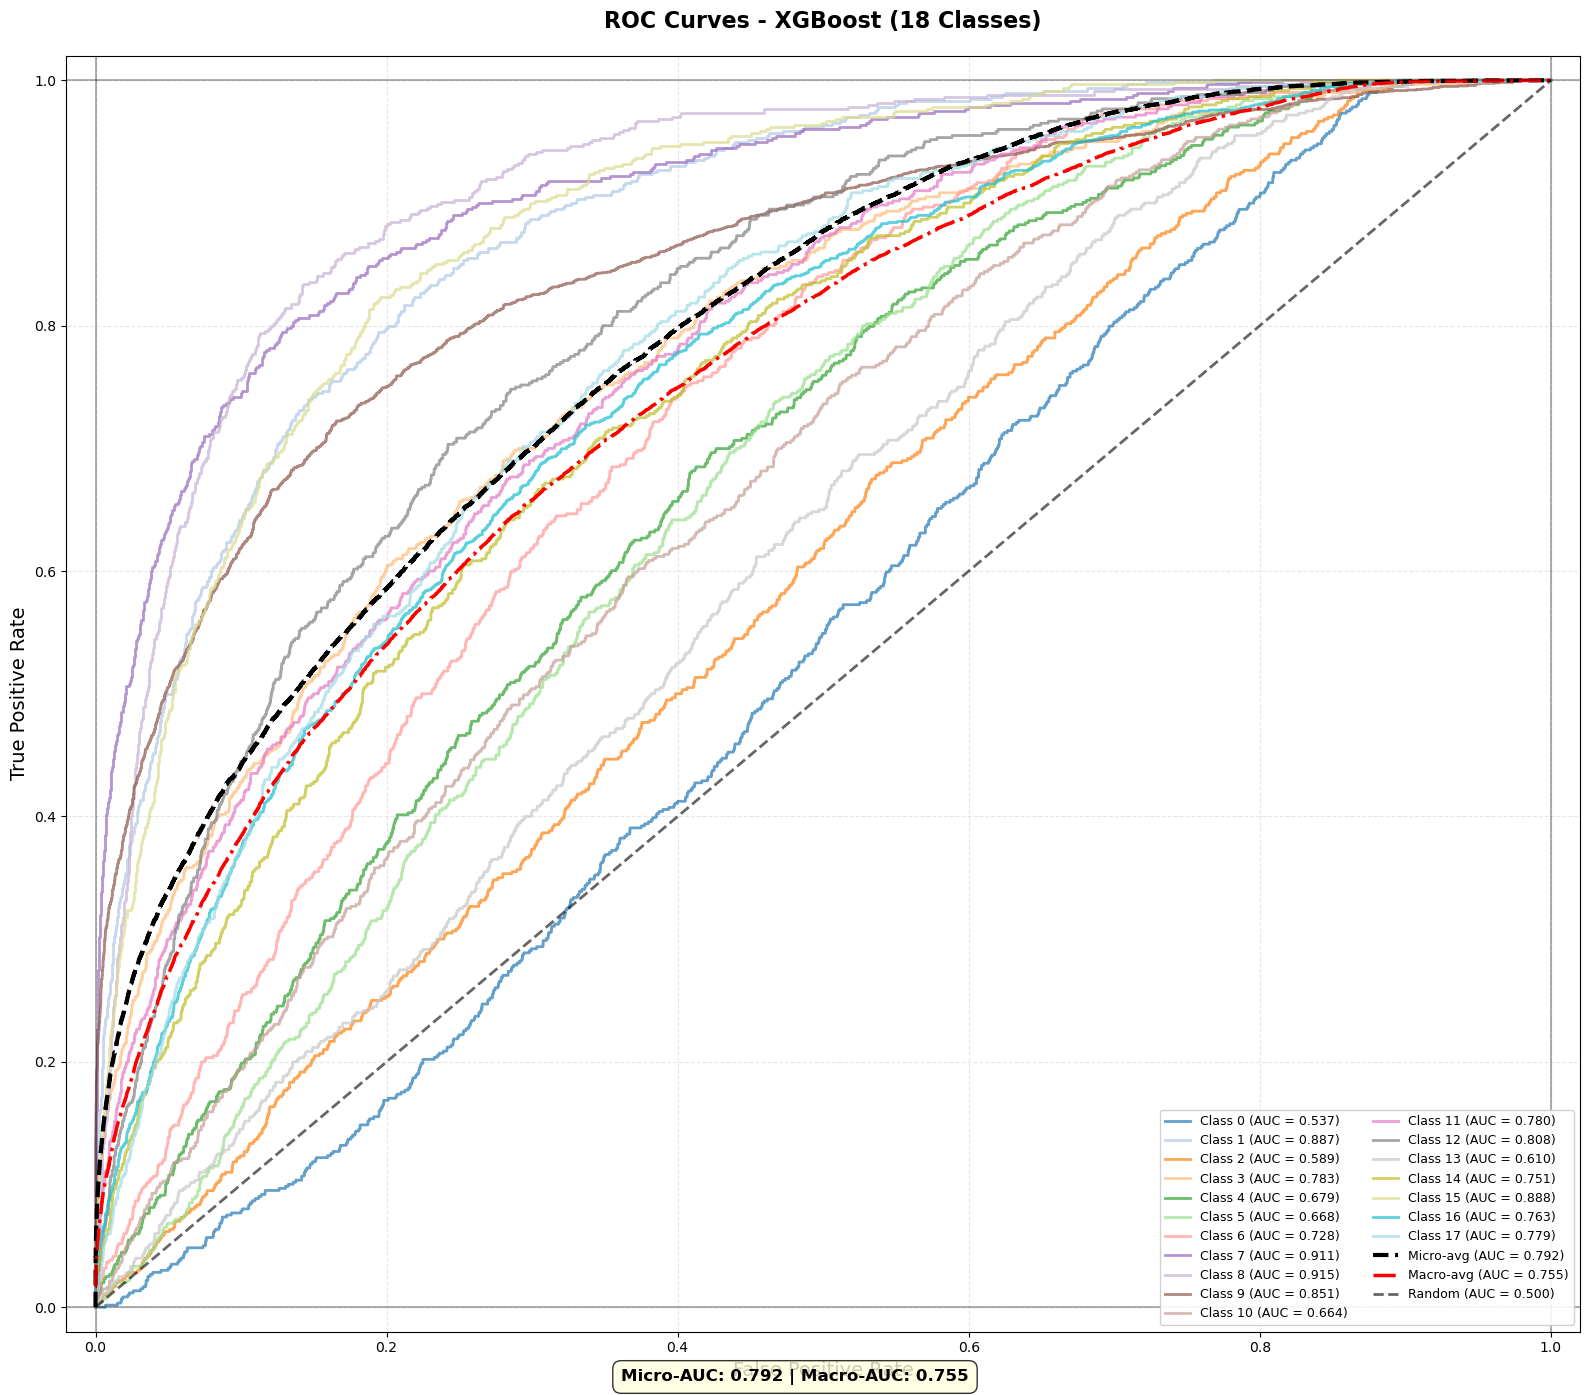

✓ ROC curve saved as 'roc_curve_xgboost.png'

COMPLETE

Generated:
  • confusion_matrix_xgboost.png
  • roc_curve_xgboost.png


In [4]:
# ==================== XGBOOST ROC & CONFUSION MATRIX ONLY ====================
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("XGBOOST - ROC Curve & Confusion Matrix")
print("="*60)

# Load saved embeddings + labels
X = np.load("distilbert_embeddings.npy")
y = np.load("labels.npy")

# Filter to only classes 0-21 if needed
mask = y < 21
X = X[mask]
y = y[mask]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Get classes (0-17)
classes = np.sort(np.unique(y))
n_classes = len(classes)
print(f"Classes: {n_classes} (0-{n_classes-1})")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

# Train XGBoost
print("\nTraining XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"\nPerformance Metrics:")
print(f"Accuracy:    {acc:.4f}")
print(f"Precision:   {prec:.4f}")
print(f"Recall:      {rec:.4f}")
print(f"F1-Score:    {f1:.4f}")

# ==================== CONFUSION MATRIX ====================
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'},
            square=True,
            annot_kws={'fontsize': 9})

plt.title(f'Confusion Matrix - XGBoost ({n_classes} Classes)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

# Add metrics to plot
metrics_text = f'Acc: {acc:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}'
plt.figtext(0.5, 0.01, metrics_text, 
            ha='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

plt.tight_layout()
plt.savefig('confusion_matrix_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Confusion matrix saved as 'confusion_matrix_xgboost.png'")

# ==================== ROC CURVES ====================
print("\nGenerating ROC Curves...")
# Binarize labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=classes)

# Compute ROC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(16, 14))
colors = plt.cm.tab20(np.linspace(0, 1, n_classes))

# Plot each class
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, alpha=0.7,
            label=f'Class {i} (AUC = {roc_auc[i]:.3f})')

# Micro-average
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='black', lw=3, linestyle='--',
        label=f'Micro-avg (AUC = {roc_auc_micro:.3f})')

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
roc_auc_macro = auc(all_fpr, mean_tpr)
plt.plot(all_fpr, mean_tpr, color='red', lw=2.5, linestyle='-.',
        label=f'Macro-avg (AUC = {roc_auc_macro:.3f})')

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.6, label='Random (AUC = 0.500)')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title(f'ROC Curves - XGBoost ({n_classes} Classes)', 
          fontsize=16, fontweight='bold', pad=20)

# Legend
plt.legend(loc='lower right', fontsize=9, ncol=2, frameon=True, 
           framealpha=0.9)

plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=0, color='k', alpha=0.3)
plt.axvline(x=0, color='k', alpha=0.3)
plt.axhline(y=1, color='k', alpha=0.3)
plt.axvline(x=1, color='k', alpha=0.3)

# Add AUC summary
auc_text = f'Micro-AUC: {roc_auc_micro:.3f} | Macro-AUC: {roc_auc_macro:.3f}'
plt.figtext(0.5, 0.01, auc_text, 
            ha='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.savefig('roc_curve_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ ROC curve saved as 'roc_curve_xgboost.png'")

print("\n" + "="*60)
print("COMPLETE")
print("="*60)
print("\nGenerated:")
print("  • confusion_matrix_xgboost.png")
print("  • roc_curve_xgboost.png")